In [ ]:
# Import des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data_rent = pd.read_csv('../datasets/rent_prediction.csv')
data_employee = pd.read_csv('../datasets/employee_satisfaction.csv')

### Question 3.1
Quel est le loyer mensuel moyen dans rent_prediction.csv, et quelle est sa dispersion (écart-type, minimum, maximum) ?

Le loyer mensuel moyen représente la valeur centrale des loyers observés dans le dataset.
L'écart-type mesure la dispersion autour de cette moyenne : plus il est élevé, plus les loyers sont hétérogènes.
Le minimum et le maximum permettent d'observer l'étendue des valeurs.

In [2]:
data_rent["LoyerMensuel_BIF"].describe()

count    5.100000e+02
mean     1.244608e+06
std      7.004331e+05
min      1.361490e+05
25%      6.999250e+05
50%      1.082640e+06
75%      1.680108e+06
max      2.600000e+06
Name: LoyerMensuel_BIF, dtype: float64

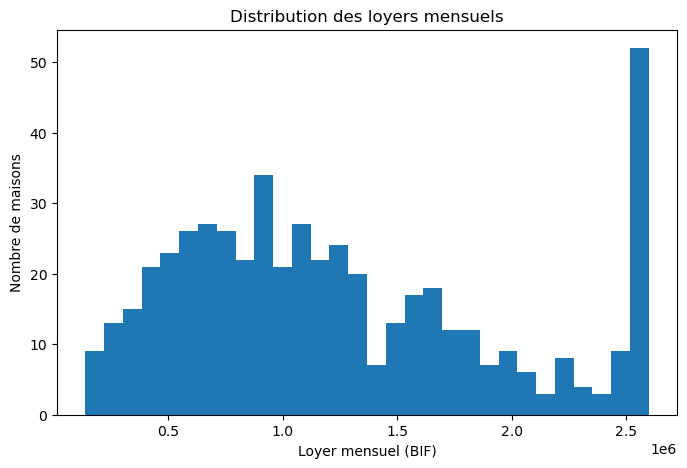

In [3]:
plt.figure(figsize=(8,5))
plt.hist(data_rent["LoyerMensuel_BIF"], bins=30)
plt.xlabel("Loyer mensuel (BIF)")
plt.ylabel("Nombre de maisons")
plt.title("Distribution des loyers mensuels")
plt.show()

### Question 3.2
Quel quartier affiche les loyers moyens les plus élevés ? Quel quartier affiche les loyers les plus bas ?

Le regroupement par quartier permet de comparer le niveau moyen des loyers selon la localisation.
Le quartier avec la moyenne la plus élevée correspond généralement aux zones les plus demandées.

In [4]:
loyer_quartier = (
    data_rent
    .groupby("Quartier")["LoyerMensuel_BIF"]
    .mean()
    .sort_values()
)

loyer_quartier

Quartier
Bwiza         5.986666e+05
Buyenzi       6.066935e+05
Kinama        7.053754e+05
Kamenge       7.669090e+05
Musaga        8.901474e+05
Jabe          9.563693e+05
Cibitoke      9.961006e+05
Nyakabiga     1.095939e+06
Ngagara       1.368809e+06
Kinanira      1.410618e+06
Gihosha       1.482161e+06
Gasekebuye    1.865619e+06
Kiriri        1.950949e+06
Rohero        2.140383e+06
Name: LoyerMensuel_BIF, dtype: float64

In [5]:
quartier_max = loyer_quartier.idxmax()
loyer_max = loyer_quartier.max()

quartier_max, loyer_max

('Rohero', 2140382.794117647)

In [6]:
quartier_min = loyer_quartier.idxmin()
loyer_min = loyer_quartier.min()

quartier_min, loyer_min

('Bwiza', 598666.5952380953)

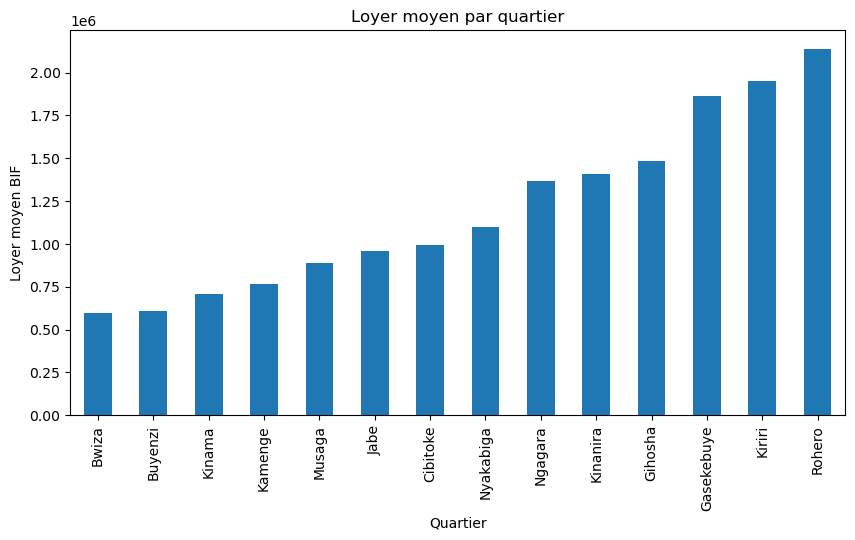

In [7]:
loyer_quartier.plot(kind="bar", figsize=(10,5))

plt.title("Loyer moyen par quartier")
plt.xlabel("Quartier")
plt.ylabel("Loyer moyen BIF")
plt.show()

### Question 3.3
Existe-t-il des valeurs manquantes dans les deux datasets ? Sont-elles concentrées sur certaines lignes/colonnes ou dispersées de façon homogène ?

On vérifie le nombre de valeurs absentes par colonne.
Si les valeurs manquantes apparaissent dans plusieurs colonnes et lignes différentes, elles sont dispersées.
Si certaines colonnes concentrent les valeurs absentes, un traitement spécifique est nécessaire.

In [8]:
data_rent.isnull().sum()

IdentifiantMaison         0
Chambres                 25
Salon                    25
SalleDeBainInterieure    25
Parking                  25
Meuble                   25
Jardin                   25
Superficie_m2            25
DistanceRoute_m          25
Quartier                 25
AgeMaison                25
LoyerMensuel_BIF          0
dtype: int64

In [9]:
data_employee.isnull().sum()

ID_Employe                 0
Age                       25
Sexe                      25
Departement               25
Annees_Experience         25
Niveau_Etudes             25
Salaire_Mensuel_BIF       25
Travail_A_Distance        25
Heures_Supplementaires    25
Heures_Formation          25
Anciennete_Entreprise     25
Nombre_Promotions         25
Evaluation_Performance    25
Equilibre_Vie_Travail     25
Satisfaction_Salaire      25
Nombre_Absences           25
Satisfait                  0
dtype: int64

In [10]:
print(
    "Rent :",
    data_rent.isnull().sum().sum()
)

print(
    "Employee :",
    data_employee.isnull().sum().sum()
)

Rent : 250
Employee : 375


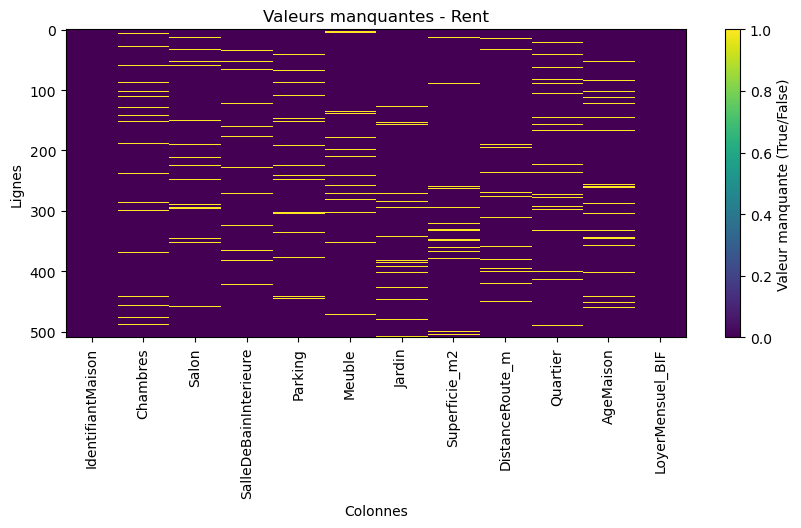

In [35]:
plt.figure(figsize=(10,4))

plt.imshow(
    data_rent.isnull(),
    aspect="auto",
    interpolation="nearest"
)

plt.title("Valeurs manquantes - Rent")

plt.xlabel("Colonnes")
plt.ylabel("Lignes")

# Afficher les noms des colonnes
plt.xticks(
    range(len(data_rent.columns)),
    data_rent.columns,
    rotation=90
)

plt.colorbar(label="Valeur manquante (True/False)")

plt.show()

### Question 3.4
Existe-t-il des lignes dupliquées dans l'un des deux datasets ? Si oui, combien ?

Une ligne dupliquée signifie qu'une observation apparaît plusieurs fois dans le dataset.
Cela peut biaiser les statistiques et les modèles de Machine Learning.

In [12]:
data_rent.duplicated().sum()

0

In [13]:
data_employee.duplicated().sum()

0

In [14]:
data_rent[data_rent.duplicated()]

,IdentifiantMaison,Chambres,Salon,SalleDeBainInterieure,Parking,Meuble,Jardin,Superficie_m2,DistanceRoute_m,Quartier,AgeMaison,LoyerMensuel_BIF


### Question 3.5
Quel département affiche le salaire moyen le plus élevé dans employee_satisfaction.csv ? Quel département affiche le salaire moyen le plus bas ?

Le salaire moyen par département permet d'identifier les différences de rémunération entre services.

In [15]:
salaire_departement = (
    data_employee
    .groupby("Departement")["Salaire_Mensuel_BIF"]
    .mean()
    .sort_values()
)

salaire_departement

Departement
Production                    2.012357e+06
Support Client                2.053510e+06
Commercial                    2.208388e+06
Administration                2.447688e+06
Marketing                     2.503896e+06
Logistique                    2.516394e+06
Recherche et Développement    2.695685e+06
Informatique                  2.823860e+06
Ressources Humaines           3.040943e+06
Finance                       3.260001e+06
Name: Salaire_Mensuel_BIF, dtype: float64

In [16]:
salaire_departement.idxmax(), salaire_departement.max()

('Finance', 3260001.054054054)

In [17]:
salaire_departement.idxmin(), salaire_departement.min()

('Production', 2012357.111111111)

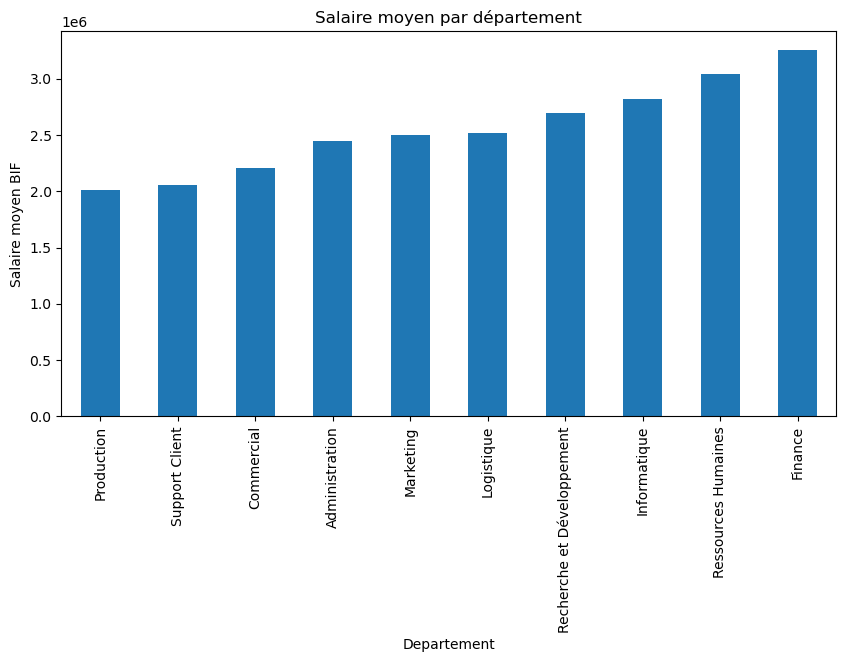

In [18]:
salaire_departement.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Salaire moyen par département")
plt.ylabel("Salaire moyen BIF")
plt.show()

### Question 3.6
Quel pourcentage global des employés est satisfait (Satisfait == "Oui") ? Ce taux varie-t-il fortement d'un département à l'autre ?

La proportion d'employés satisfaits est une estimation de la probabilité qu'un employé choisi aléatoirement soit satisfait.

In [19]:
taux_global = (
    data_employee["Satisfait"]
    .eq("Oui")
    .mean()
)

taux_global

0.6

In [20]:
satisfaction_dept = (
    data_employee
    .groupby("Departement")["Satisfait"]
    .apply(lambda x: (x=="Oui").mean()*100)
)

satisfaction_dept

Departement
Administration                63.461538
Commercial                    58.695652
Finance                       60.000000
Informatique                  59.183673
Logistique                    47.916667
Marketing                     51.063830
Production                    62.500000
Recherche et Développement    69.565217
Ressources Humaines           58.490566
Support Client                68.750000
Name: Satisfait, dtype: float64

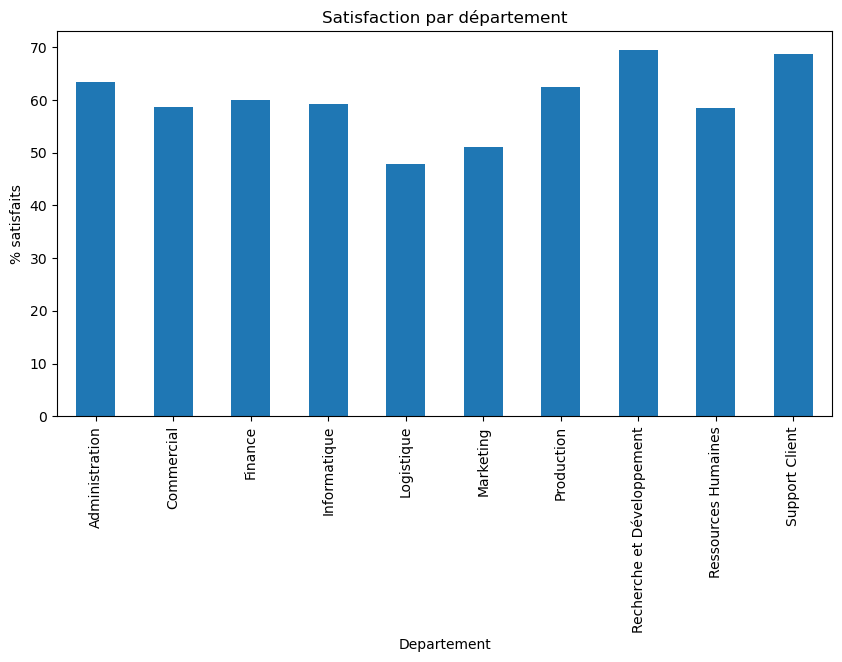

In [21]:
satisfaction_dept.plot(
    kind="bar",
    figsize=(10,5)
)

plt.ylabel("% satisfaits")
plt.title("Satisfaction par département")
plt.show()

### Question 3.7
Quels facteurs semblent influencer le plus le loyer (superficie, quartier, type de logement, distance au centre-ville...) ?

La corrélation permet d'étudier les relations entre variables numériques.
Une corrélation positive signifie que les deux variables augmentent ensemble.
Pour les variables catégorielles comme le quartier, on utilise plutôt une comparaison des moyennes.

In [22]:
data_rent.corr(numeric_only=True)["LoyerMensuel_BIF"].sort_values()

DistanceRoute_m      0.015409
AgeMaison            0.022581
IdentifiantMaison    0.041912
Superficie_m2        0.615623
Chambres             0.623275
LoyerMensuel_BIF     1.000000
Name: LoyerMensuel_BIF, dtype: float64

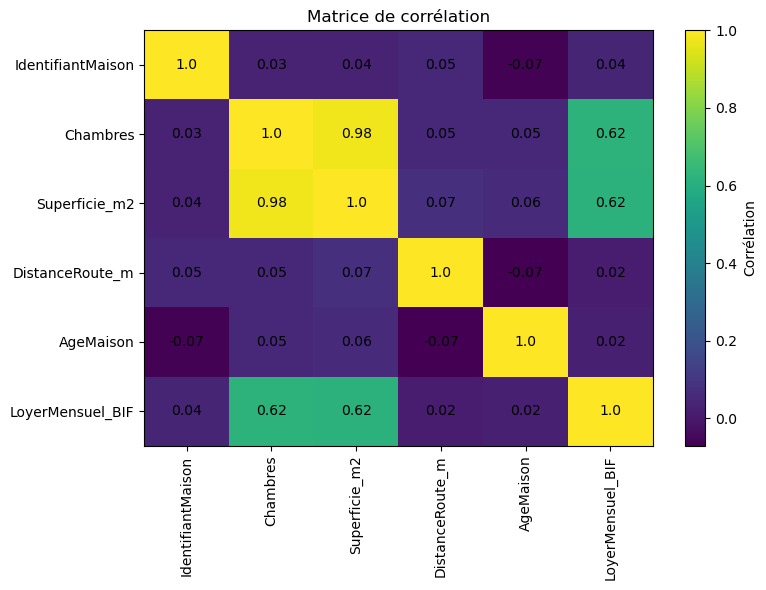

In [36]:
# Calcul de la matrice de corrélation
corr = data_rent.corr(numeric_only=True)

plt.figure(figsize=(8,6))

# Affichage de la matrice
plt.imshow(
    corr,
    interpolation="nearest",
    aspect="auto"
)

plt.title("Matrice de corrélation")

# Noms des variables
plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

# Ajouter les valeurs dans les cases
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(
            j,
            i,
            round(corr.iloc[i, j], 2),
            ha="center",
            va="center"
        )

# Barre d'échelle
plt.colorbar(label="Corrélation")

plt.tight_layout()
plt.show()

In [24]:
# Impact du quartier    
data_rent.groupby(
    "Quartier"
)["LoyerMensuel_BIF"].mean().sort_values()

Quartier
Bwiza         5.986666e+05
Buyenzi       6.066935e+05
Kinama        7.053754e+05
Kamenge       7.669090e+05
Musaga        8.901474e+05
Jabe          9.563693e+05
Cibitoke      9.961006e+05
Nyakabiga     1.095939e+06
Ngagara       1.368809e+06
Kinanira      1.410618e+06
Gihosha       1.482161e+06
Gasekebuye    1.865619e+06
Kiriri        1.950949e+06
Rohero        2.140383e+06
Name: LoyerMensuel_BIF, dtype: float64

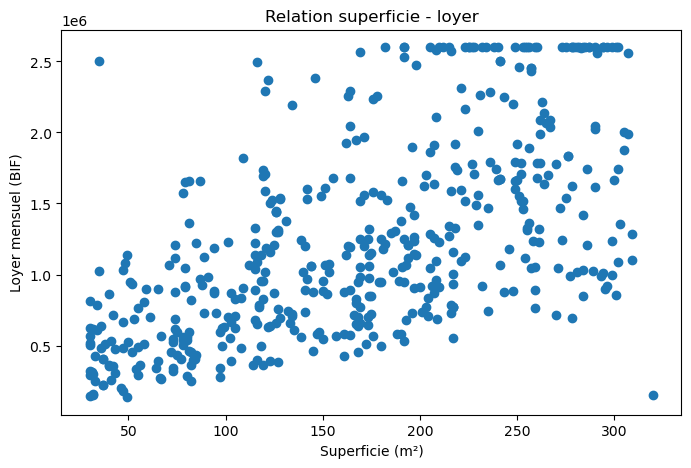

In [37]:
plt.figure(figsize=(8,5))

plt.scatter(
    data_rent["Superficie_m2"],
    data_rent["LoyerMensuel_BIF"]
)

plt.title("Relation superficie - loyer")
plt.xlabel("Superficie (m²)")
plt.ylabel("Loyer mensuel (BIF)")

plt.show()

### Question 3.8
Quelles variables de employee_satisfaction.csv semblent le plus corrélées avec la satisfaction globale ?

La satisfaction est une variable qualitative.
On peut comparer les moyennes des variables numériques selon les groupes satisfaits/non satisfaits.

In [26]:
data_employee.groupby(
    "Satisfait"
).mean(numeric_only=True)

,ID_Employe,Age,Annees_Experience,Salaire_Mensuel_BIF,Heures_Supplementaires,Heures_Formation,Anciennete_Entreprise,Nombre_Promotions,Evaluation_Performance,Nombre_Absences
Satisfait,,,,,,,,,,
Non,244.230392,40.517949,9.715026,2.418013e+06,20.898990,52.15736,4.290155,0.822917,2.621762,17.302564
Oui,263.013072,41.151724,11.517123,2.679480e+06,18.369338,66.28125,6.051370,1.447099,3.075342,13.655172


In [27]:
data_employee["Satisfait_num"] = (
    data_employee["Satisfait"]
    .map({"Oui":1,"Non":0})
)


correlations = (
    data_employee
    .corr(numeric_only=True)["Satisfait_num"]
    .sort_values()
)

correlations

Nombre_Absences          -0.205868
Heures_Supplementaires   -0.108439
Age                       0.026060
ID_Employe                0.062501
Salaire_Mensuel_BIF       0.072207
Annees_Experience         0.099438
Anciennete_Entreprise     0.147564
Evaluation_Performance    0.153270
Heures_Formation          0.199115
Nombre_Promotions         0.219776
Satisfait_num             1.000000
Name: Satisfait_num, dtype: float64

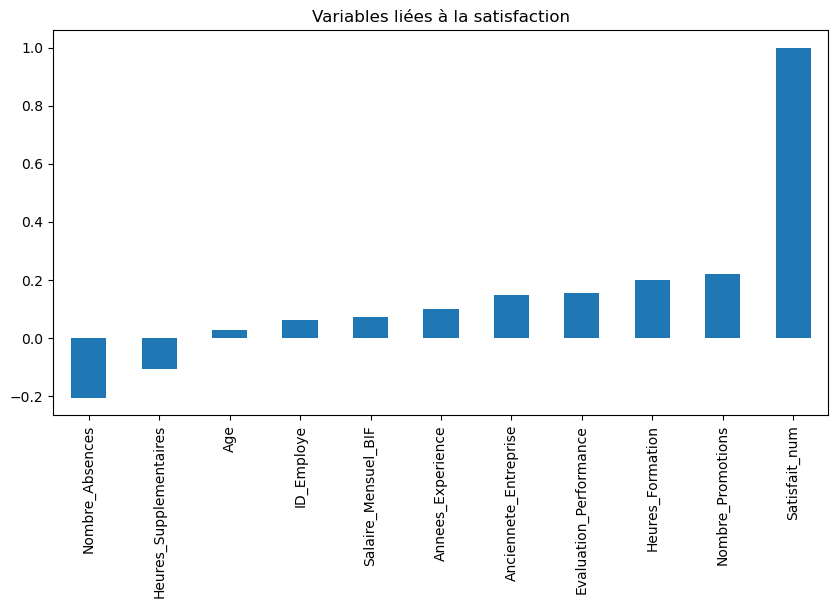

In [28]:
correlations.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Variables liées à la satisfaction")
plt.show()

### Question 3.9
Existe-t-il une relation visible entre l'équilibre vie professionnelle/personnelle (Equilibre_Vie_Travail) et la satisfaction (Satisfait) ?

On compare le taux de satisfaction pour chaque niveau d'équilibre vie-travail.

In [29]:
equilibre = (
    data_employee
    .groupby("Equilibre_Vie_Travail")
    ["Satisfait"]
    .apply(lambda x:(x=="Oui").mean()*100)
)

equilibre

Equilibre_Vie_Travail
Bon             79.268293
Excellent       84.782609
Mauvais         38.805970
Moyen           57.792208
Très mauvais    11.111111
Name: Satisfait, dtype: float64

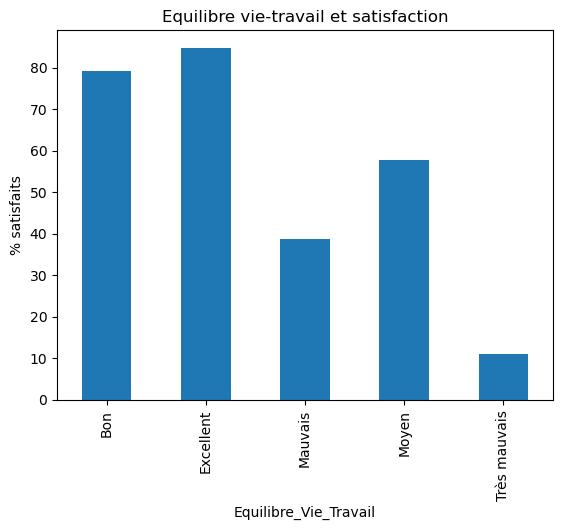

In [30]:
equilibre.plot(kind="bar")

plt.ylabel("% satisfaits")
plt.title(
    "Equilibre vie-travail et satisfaction"
)

plt.show()

### Question 3.10
Le nombre d'heures supplémentaires (Heures_Supplementaires) et le nombre d'absences (Nombre_Absences) semblent-ils liés à la satisfaction des employés ?

On compare les moyennes des heures supplémentaires et des absences selon la satisfaction.

Si les employés insatisfaits ont beaucoup plus d'heures supplémentaires ou d'absences, cela peut indiquer une relation.

In [31]:
data_employee.groupby(
    "Satisfait"
)[
    [
        "Heures_Supplementaires",
        "Nombre_Absences"
    ]
].mean()

,Heures_Supplementaires,Nombre_Absences
Satisfait,,
Non,20.898990,17.302564
Oui,18.369338,13.655172


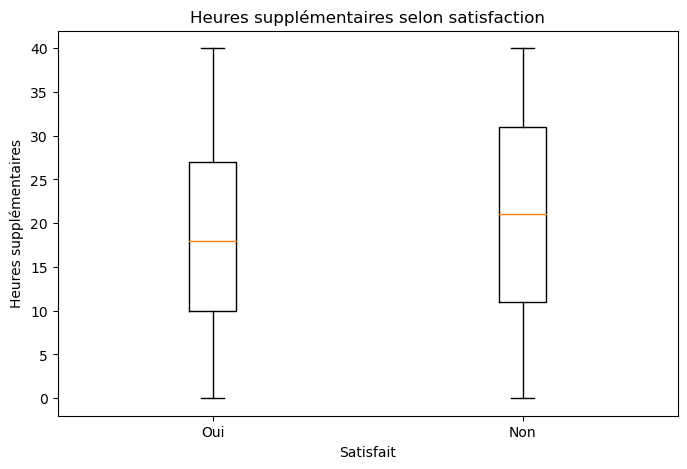

In [38]:
# Séparer les données selon la satisfaction
heures_oui = data_employee[
    data_employee["Satisfait"] == "Oui"
]["Heures_Supplementaires"]

heures_non = data_employee[
    data_employee["Satisfait"] == "Non"
]["Heures_Supplementaires"]

plt.figure(figsize=(8,5))

plt.boxplot(
    [
        heures_oui.dropna(),
        heures_non.dropna()
    ],
    labels=["Oui", "Non"]
)

plt.title(
    "Heures supplémentaires selon satisfaction"
)

plt.xlabel("Satisfait")
plt.ylabel("Heures supplémentaires")

plt.show()

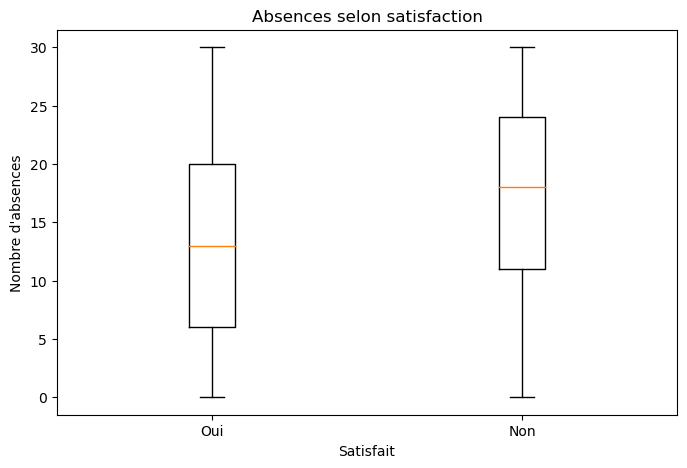

In [39]:
# Séparer les absences selon la satisfaction
absences_oui = data_employee[
    data_employee["Satisfait"] == "Oui"
]["Nombre_Absences"]

absences_non = data_employee[
    data_employee["Satisfait"] == "Non"
]["Nombre_Absences"]

plt.figure(figsize=(8,5))

plt.boxplot(
    [
        absences_oui.dropna(),
        absences_non.dropna()
    ],
    labels=["Oui", "Non"]
)

plt.title(
    "Absences selon satisfaction"
)

plt.xlabel("Satisfait")
plt.ylabel("Nombre d'absences")

plt.show()